In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import (silhouette_score,accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)

from sklearn.model_selection import (train_test_split,GridSearchCV,cross_val_score)
%matplotlib inline
df = pd.read_csv(r"E:\computer science (Mostafa)\IEEE AI Task\IEEE-AI-Ambassadors-2026\Task_09\CC GENERAL.csv")
df

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8945,C19186,28.493517,1.000000,291.12,0.00,291.12,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,325.594462,48.886365,0.500000,6
8946,C19187,19.183215,1.000000,300.00,0.00,300.00,0.000000,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,275.861322,NaN,0.000000,6
8947,C19188,23.398673,0.833333,144.40,0.00,144.40,0.000000,0.833333,0.000000,0.666667,0.000000,0,5,1000.0,81.270775,82.418369,0.250000,6
8948,C19189,13.457564,0.833333,0.00,0.00,0.00,36.558778,0.000000,0.000000,0.000000,0.166667,2,0,500.0,52.549959,55.755628,0.250000,6


## Data Exploration 

In [60]:
df.shape

(8950, 18)

In [61]:
df.ndim

2

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   str    
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHASES_TRX    

In [63]:
miss = df.isnull().sum().sort_values(ascending=False)
miss_per = ((df.isnull().sum() / len(df)) * 100).round(2).sort_values(ascending=False)
pd.DataFrame({"Missing Values": miss, "Missing Percentage": miss_per})[miss > 0]

,Missing Values,Missing Percentage
MINIMUM_PAYMENTS,313,3.50
CREDIT_LIMIT,1,0.01


In [64]:
df.duplicated().sum()

np.int64(0)

In [65]:
skewness = df.skew(numeric_only=True).sort_values(ascending=False)
print(skewness)

MINIMUM_PAYMENTS                    13.622797
ONEOFF_PURCHASES                    10.045083
PURCHASES                            8.144269
INSTALLMENTS_PURCHASES               7.299120
PAYMENTS                             5.907620
CASH_ADVANCE_TRX                     5.721298
CASH_ADVANCE                         5.166609
PURCHASES_TRX                        4.630655
BALANCE                              2.393386
PRC_FULL_PAYMENT                     1.942820
CASH_ADVANCE_FREQUENCY               1.828686
ONEOFF_PURCHASES_FREQUENCY           1.535613
CREDIT_LIMIT                         1.522464
PURCHASES_INSTALLMENTS_FREQUENCY     0.509201
PURCHASES_FREQUENCY                  0.060164
BALANCE_FREQUENCY                   -2.023266
TENURE                              -2.943017
dtype: float64


In [66]:
df.drop("CUST_ID", axis=1, inplace=True)


## Outlier Remove

In [67]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_count = ((df < lower_bound) | (df > upper_bound)).sum(axis=1)
outlier_mask = outlier_count >= 3   

df_clean = df.loc[~outlier_mask].copy()

print("Original:", df.shape)
print("Cleaned:", df_clean.shape)
print("Removed:", outlier_mask.sum())

Original: (8950, 17)
Cleaned: (7139, 17)
Removed: 1811


## Log Transformation and  Feature Scaling  and Data Spliting

In [68]:
X_train , X_test = train_test_split(df_clean ,random_state=42 ,train_size = 0.8)

In [69]:
class LogTransformer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = np.asarray(X)
        return np.log1p(X)


In [70]:
preprocessing_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log_transform", LogTransformer()),
    ("scaler", RobustScaler())
])


In [71]:
X_train_scaled = preprocessing_pipeline.fit_transform(X_train)
X_test_scaled = preprocessing_pipeline.transform(X_test)

feature_names = X_train.columns

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=feature_names,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=feature_names,
    index=X_test.index
)

X_train_scaled.head()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
6302,-0.932587,0.0,0.141574,0.000000,0.315661,0.000000,0.608630,0.000000,0.963154,0.000000,0.000000,0.564575,-0.301414,-0.430706,-0.310738,6.826005,0.000000
5551,-1.169907,0.0,-0.163052,0.000000,0.150583,0.000000,0.608630,0.000000,0.880026,0.000000,0.000000,0.276989,-0.540312,-1.094621,-0.373582,6.036756,-0.080043
8276,0.364106,0.0,-1.768452,0.000000,-0.719388,1.035967,-0.614748,0.000000,-0.275459,1.000000,0.792481,-1.000000,-0.116086,-0.227549,0.518641,0.000000,0.000000
3764,0.172077,0.0,-0.062410,0.000000,0.205121,0.608316,0.608630,0.000000,0.887103,0.519247,0.792481,0.318123,-0.725585,-0.203904,0.582708,0.000000,0.000000
1880,0.195756,0.0,0.518588,1.222293,0.255599,0.000000,0.608630,2.259518,0.963154,0.000000,0.000000,0.611325,0.035351,-0.480282,0.287871,0.000000,0.000000


In [72]:
skewnesss = X_train_scaled.skew()
print(skewnesss)

BALANCE                            -0.841875
BALANCE_FREQUENCY                  -2.205162
PURCHASES                          -0.847260
ONEOFF_PURCHASES                    0.317472
INSTALLMENTS_PURCHASES             -0.020474
CASH_ADVANCE                        0.341727
PURCHASES_FREQUENCY                 0.025468
ONEOFF_PURCHASES_FREQUENCY          1.684882
PURCHASES_INSTALLMENTS_FREQUENCY    0.456228
CASH_ADVANCE_FREQUENCY              1.388033
CASH_ADVANCE_TRX                    0.906353
PURCHASES_TRX                      -0.130139
CREDIT_LIMIT                       -0.015750
PAYMENTS                           -2.228544
MINIMUM_PAYMENTS                    0.182708
PRC_FULL_PAYMENT                    1.982070
TENURE                             -3.295657
dtype: float64


In [73]:
skewnessss = X_test_scaled.skew()
print(skewnessss)

BALANCE                            -0.861983
BALANCE_FREQUENCY                  -2.041053
PURCHASES                          -0.798461
ONEOFF_PURCHASES                    0.241963
INSTALLMENTS_PURCHASES              0.062488
CASH_ADVANCE                        0.337485
PURCHASES_FREQUENCY                 0.072478
ONEOFF_PURCHASES_FREQUENCY          1.659539
PURCHASES_INSTALLMENTS_FREQUENCY    0.523869
CASH_ADVANCE_FREQUENCY              1.505204
CASH_ADVANCE_TRX                    0.943190
PURCHASES_TRX                      -0.085795
CREDIT_LIMIT                       -0.061218
PAYMENTS                           -2.296902
MINIMUM_PAYMENTS                    0.347998
PRC_FULL_PAYMENT                    1.994857
TENURE                             -3.482225
dtype: float64


## Kmeans

In [74]:
k_values = range(2, 11)
inertias = []
silhouette_scores = []
for k in k_values:
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=20)
    labels = kmeans.fit_predict(X_train_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled, labels))

,k,Inertia,Silhouette
0,2,62525.921796,0.365925
1,3,46566.154654,0.391544
2,4,37478.993824,0.283315
3,5,33353.349259,0.268059
4,6,31059.918134,0.262259
5,7,28998.829410,0.260060
6,8,27310.509077,0.245283
7,9,25755.297089,0.250797
8,10,24593.398203,0.235034


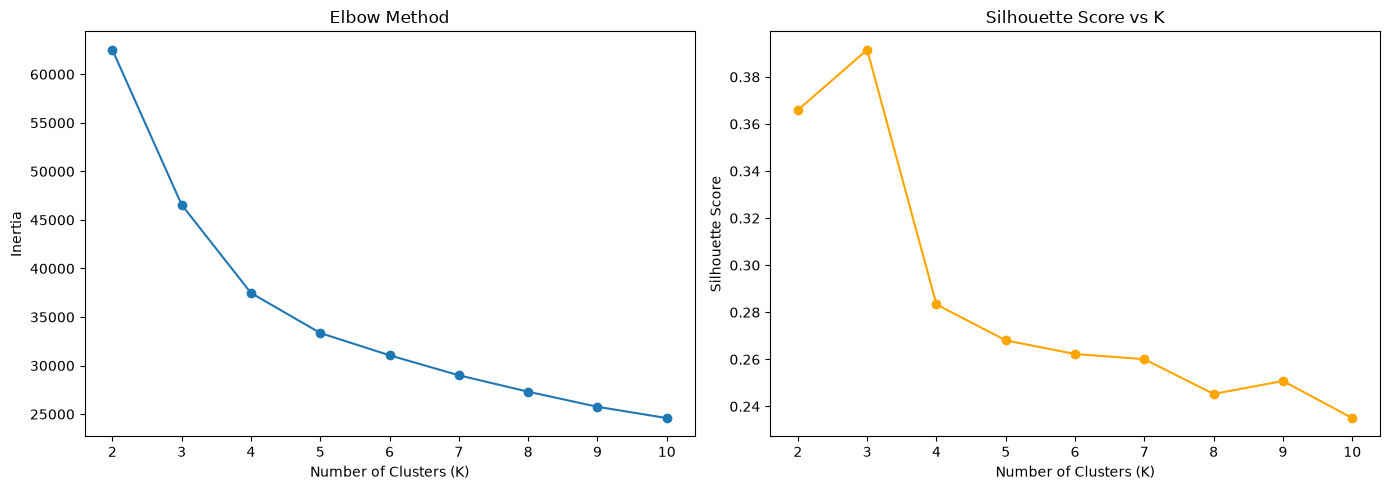

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_k = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

results_k["k"] = results_k["K"]
results_k["Silhouette"] = results_k["Silhouette Score"]

axes[0].plot(results_k["K"], results_k["Inertia"], marker="o")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(results_k["k"], results_k["Silhouette"], marker="o", color="orange")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs K")

plt.tight_layout()
plt.show()

In [85]:
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k,random_state=42,n_init=10)
    
    labels = kmeans.fit_predict(X_train_scaled)
    
    score = silhouette_score(X_train_scaled, labels)
    silhouette_scores.append(score)

In [86]:
best_k_by_silhouette = results_k.loc[results_k["Silhouette Score"].idxmax(),"K"]

print("Best K according to Silhouette Score:",  best_k_by_silhouette)


Best K according to Silhouette Score: 3


In [87]:
FINAL_K = int(best_k_by_silhouette)


In [88]:
kmeans_final = KMeans(
    n_clusters=FINAL_K,
    random_state=42,
    n_init=20
)

train_clusters = kmeans_final.fit_predict(X_train_scaled)
test_clusters = kmeans_final.predict(X_test_scaled)


In [89]:
print("Train cluster distribution:")
print(pd.Series(train_clusters).value_counts().sort_index())

print("\nTest cluster distribution:")
print(pd.Series(test_clusters).value_counts().sort_index())


Train cluster distribution:
0     862
1    4142
2     707
Name: count, dtype: int64

Test cluster distribution:
0     220
1    1013
2     195
Name: count, dtype: int64


In [90]:
cluster_distribution = (
    pd.Series(train_clusters)
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

cluster_distribution


0    15.09
1    72.53
2    12.38
Name: proportion, dtype: float64

In [91]:
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)

pca_df = pd.DataFrame(
    X_train_pca,
    columns=["PC1", "PC2"],
    index=X_train_scaled.index
)

pca_df["Cluster"] = train_clusters

pca_df.head()

,PC1,PC2,Cluster
6302,5.213984,2.487244,0
5551,4.563783,1.865680,0
8276,-2.016672,-0.217545,1
3764,-1.198325,0.478028,1
1880,-0.667598,1.154920,1


In [92]:
pca = PCA(n_components=2, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)

pca_df = pd.DataFrame(
    X_train_pca,
    columns=["PC1", "PC2"],
    index=X_train_scaled.index
)

pca_df["Cluster"] = train_clusters

print(
    "Explained variance:",
    pca.explained_variance_ratio_
)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)


Explained variance: [0.33737704 0.25473672]
Total explained variance: 0.5921137595391526


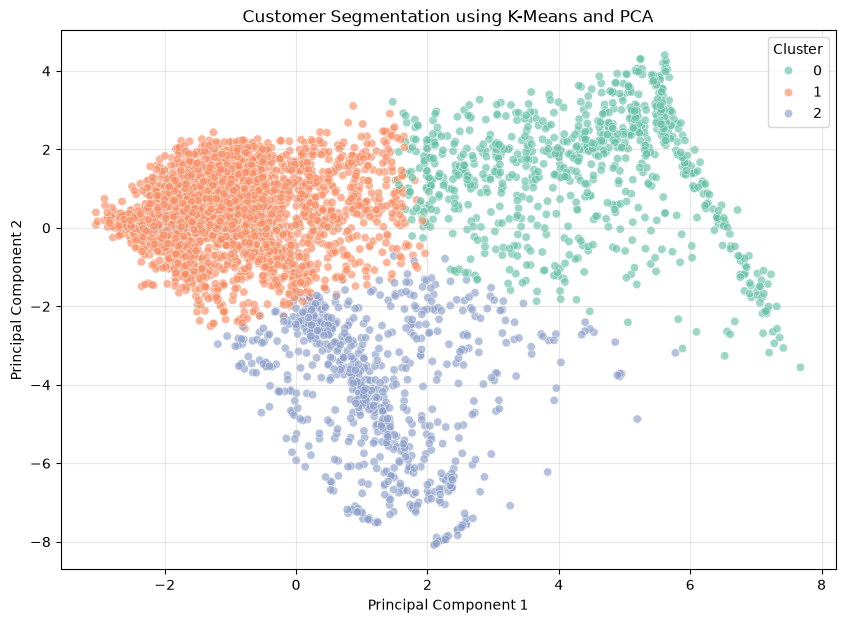

In [93]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    alpha=0.65
)

plt.title("Customer Segmentation using K-Means and PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(alpha=0.3)
plt.show()


In [94]:
X_train_profile = X_train.copy()

X_train_profile["Cluster"] = train_clusters

cluster_profile = (
    X_train_profile
    .groupby("Cluster")
    .mean()
    .round(2)
)

cluster_profile


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,83.62,0.84,741.94,231.97,510.08,35.62,0.78,0.17,0.63,0.01,0.13,14.32,4055.72,876.68,154.12,0.70,11.52
1,1530.79,0.97,539.33,305.11,234.49,744.23,0.42,0.16,0.31,0.14,2.79,9.45,3631.89,1120.13,831.45,0.03,11.59
2,84.89,0.32,262.70,147.40,116.26,278.17,0.28,0.06,0.21,0.04,0.73,4.32,3338.92,693.44,123.25,0.05,11.35


In [95]:
cluster_names = {0: "Active Moderate Spenders",1: "Cash Advance Users",2: "Low Activity Customers",3: "Frequent Installment Shoppers"}

In [96]:
cluster_summary = cluster_profile.copy()
cluster_summary.index = [
    cluster_names.get(i, f"Cluster {i}")
    for i in cluster_summary.index
]

cluster_summary


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Active Moderate Spenders,83.62,0.84,741.94,231.97,510.08,35.62,0.78,0.17,0.63,0.01,0.13,14.32,4055.72,876.68,154.12,0.70,11.52
Cash Advance Users,1530.79,0.97,539.33,305.11,234.49,744.23,0.42,0.16,0.31,0.14,2.79,9.45,3631.89,1120.13,831.45,0.03,11.59
Low Activity Customers,84.89,0.32,262.70,147.40,116.26,278.17,0.28,0.06,0.21,0.04,0.73,4.32,3338.92,693.44,123.25,0.05,11.35


In [97]:
y_train = train_clusters
y_test = test_clusters


In [98]:
X_train_supervised = X_train_scaled
X_test_supervised = X_test_scaled


In [99]:
y_train, y_test = train_clusters, test_clusters

models = {"Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", random_state=42),}

rows = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)          
    fitted_models[name] = model

    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    rows.append({
        "Model": name,
        "Train Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Train-Test Gap": round(train_acc - test_acc, 4),
    })

results = pd.DataFrame(rows).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results

,Model,Train Accuracy,Test Accuracy,Train-Test Gap
0,Logistic Regression,0.9988,0.9979,0.0009
1,SVM (RBF),0.9974,0.9958,0.0016
2,Random Forest,1.0000,0.9909,0.0091


In [ ]:
best_model_name = results.iloc[0]["Model"]
best_model = fitted_models[best_model_name]

print(f"أفضل موديل قبل الـ tuning: {best_model_name}")
print("\nClassification Report test set:")
print(classification_report(y_test, best_model.predict(X_test_scaled)))

In [ ]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
}

rf_for_tuning = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

In [ ]:
best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(X_test_scaled)
best_test_accuracy = accuracy_score(y_test, best_pred)

print("Tuned RF Test Accuracy:", best_test_accuracy)
print("Baseline RF Test Accuracy :",
      results.loc[results["Model"] == "Random Forest", "Test Accuracy"].values[0])